## Task 2A: Agglomerative Clustering

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


## **1. Exploratory Data Analysis (EDA)**
For each feature, you should:

- Identify **numeric vs categorical features**  
- Check **distributions** of numeric features (min, max, mean, std, skewness)  
- Check **counts of categories** for categorical features  
- Identify **missing or unknown values** and decide how to handle them  
- Look for **correlations** between numeric features  
- Identify **outliers** that may affect clustering  

In [4]:
cc_df = pd.read_csv("CC GENERAL.csv", sep=',')
cc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [5]:
cc_df.head(10)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
5,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12
6,C10007,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.000000,12
7,C10008,1823.652743,1.000000,436.20,0.00,436.20,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,2300.0,679.065082,532.033990,0.000000,12
8,C10009,1014.926473,1.000000,861.49,661.49,200.00,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.000000,12
9,C10010,152.225975,0.545455,1281.60,1281.60,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.000000,12


### Numeric VS Categorical Features

In [8]:
numeric_features = cc_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = cc_df.select_dtypes(include=['object']).columns.tolist()

print("Numeric Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)


Numeric Features:
['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']

Categorical Features:
['CUST_ID']


### Numeric Features Distribution

In [10]:
numeric_stats_summary=cc_df[numeric_features].describe().T
numeric_stats_summary['skewness']=cc_df.skew(numeric_only=True)
numeric_stats_summary

,count,mean,std,min,25%,50%,75%,max,skewness
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856,2.393386
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000,-2.023266
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000,8.144269
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000,10.045083
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000,7.299120
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176,5.166609
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000,0.060164
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000,1.535613
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000,0.509201
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000,1.828686


### Categorical Features Count

Only have one categirical feature which is CUST_ID and its unique for each customer its an identifier it will not be used in clustering.

In [13]:
cc_df = cc_df.drop("CUST_ID", axis=1)

### Missing and Unknown Values

In [14]:
sum_null_per_column=cc_df.isnull().sum()
sum_null_per_column

BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [24]:
cc_copy = cc_df.copy()
cc_copy["MINPAY_missing"] = cc_copy["MINIMUM_PAYMENTS"].isnull().astype(int)
print(cc_copy.groupby("MINPAY_missing").mean().T)
cc_copy.corr()["MINPAY_missing"].sort_values(ascending=False)


MINPAY_missing                              0            1
BALANCE                           1601.041632   555.441321
BALANCE_FREQUENCY                    0.894951     0.389403
PURCHASES                         1025.315149   393.087284
ONEOFF_PURCHASES                   604.831402   250.433387
INSTALLMENTS_PURCHASES             420.794807   142.653898
CASH_ADVANCE                       994.082050   559.136698
PURCHASES_FREQUENCY                  0.495943     0.336043
ONEOFF_PURCHASES_FREQUENCY           0.205885     0.107886
PURCHASES_INSTALLMENTS_FREQUENCY     0.368778     0.244670
CASH_ADVANCE_FREQUENCY               0.137608     0.067169
CASH_ADVANCE_TRX                     3.313651     1.460064
PURCHASES_TRX                       15.031492     5.833866
CREDIT_LIMIT                      4522.091030  3731.789137
PAYMENTS                          1784.272537   322.286168
MINIMUM_PAYMENTS                   864.206542          NaN
PRC_FULL_PAYMENT                     0.159285     0.0000

MINPAY_missing                      1.000000
CASH_ADVANCE                       -0.038103
ONEOFF_PURCHASES                   -0.039225
CREDIT_LIMIT                       -0.039904
CASH_ADVANCE_TRX                   -0.049899
PURCHASES                          -0.054362
INSTALLMENTS_PURCHASES             -0.056505
PURCHASES_INSTALLMENTS_FREQUENCY   -0.057368
ONEOFF_PURCHASES_FREQUENCY         -0.060349
TENURE                             -0.064499
CASH_ADVANCE_FREQUENCY             -0.064665
PURCHASES_TRX                      -0.067978
PURCHASES_FREQUENCY                -0.073191
BALANCE                            -0.092286
PAYMENTS                           -0.092777
PRC_FULL_PAYMENT                   -0.100047
BALANCE_FREQUENCY                  -0.392053
MINIMUM_PAYMENTS                         NaN
Name: MINPAY_missing, dtype: float64

In [22]:
cc_copy[cc_copy["MINIMUM_PAYMENTS"].isnull()]

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,MINPAY_missing
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.0,12,1
45,2242.311686,1.000000,437.00,97.00,340.0,184.648692,0.333333,0.083333,0.333333,0.166667,2,5,2400.0,0.000000,NaN,0.0,12,1
47,3910.111237,1.000000,0.00,0.00,0.0,1980.873201,0.000000,0.000000,0.000000,0.500000,7,0,4200.0,0.000000,NaN,0.0,12,1
54,6.660517,0.636364,310.00,0.00,310.0,0.000000,0.666667,0.000000,0.666667,0.000000,0,8,1000.0,417.016763,NaN,0.0,12,1
55,1311.995984,1.000000,1283.90,1283.90,0.0,0.000000,0.250000,0.250000,0.000000,0.000000,0,6,6000.0,0.000000,NaN,0.0,12,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8919,14.524779,0.333333,152.00,152.00,0.0,0.000000,0.333333,0.333333,0.000000,0.000000,0,2,1500.0,0.000000,NaN,0.0,6,1
8929,371.527312,0.333333,0.00,0.00,0.0,1465.407927,0.000000,0.000000,0.000000,0.166667,5,0,1500.0,0.000000,NaN,0.0,6,1
8935,183.817004,1.000000,465.90,0.00,465.9,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1500.0,0.000000,NaN,0.0,6,1
8944,193.571722,0.833333,1012.73,1012.73,0.0,0.000000,0.333333,0.333333,0.000000,0.000000,0,2,4000.0,0.000000,NaN,0.0,6,1


In [31]:
missing_minpay = cc_copy[cc_copy["MINIMUM_PAYMENTS"].isnull()]
print(missing_minpay["PRC_FULL_PAYMENT"].value_counts())
missing_minpay[["BALANCE","PURCHASES", "CASH_ADVANCE","TENURE","CREDIT_LIMIT"]].describe()

PRC_FULL_PAYMENT
0.0    313
Name: count, dtype: int64


,BALANCE,PURCHASES,CASH_ADVANCE,TENURE,CREDIT_LIMIT
count,313.000000,313.000000,313.000000,313.000000,313.000000
mean,555.441321,393.087284,559.136698,11.063898,3731.789137
std,1292.687887,757.905701,1185.132567,1.869734,2924.606153
min,0.000000,0.000000,0.000000,6.000000,500.000000
25%,0.187069,1.400000,0.000000,12.000000,1500.000000
50%,16.848358,130.400000,0.000000,12.000000,3000.000000
75%,286.686616,399.950000,480.104401,12.000000,5000.000000
max,9164.724752,7597.090000,7616.064965,12.000000,19500.000000


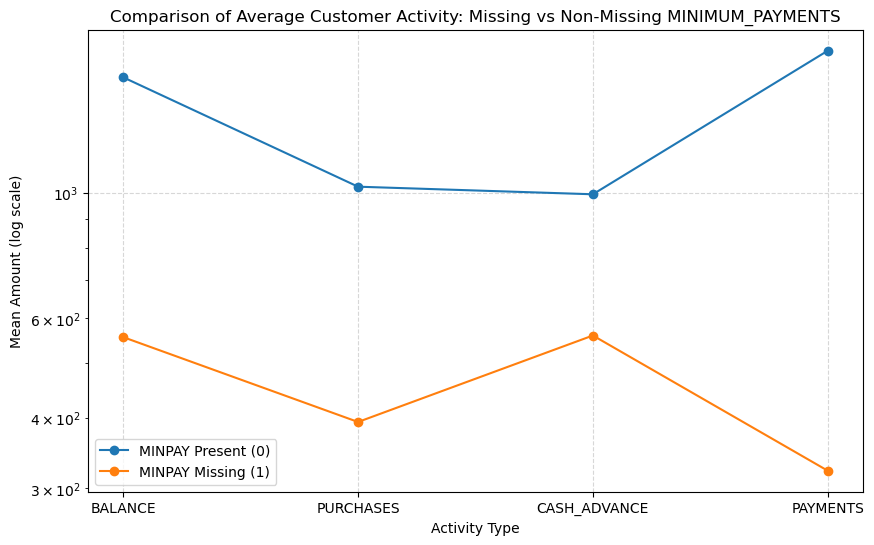

In [33]:

cc_copy["MINPAY_missing"] = cc_copy["MINIMUM_PAYMENTS"].isnull().astype(int)

# Columns representing activity
activity_cols = ["BALANCE", "PURCHASES", "CASH_ADVANCE", "PAYMENTS"]

# Compute mean per group
mean_activity = cc_copy.groupby("MINPAY_missing")[activity_cols].mean()

# Plot line graph
plt.figure(figsize=(10,6))
plt.plot(activity_cols, mean_activity.loc[0], marker='o', label="MINPAY Present (0)")
plt.plot(activity_cols, mean_activity.loc[1], marker='o', label="MINPAY Missing (1)")
plt.yscale("log")  # log scale for clarity due to skewness
plt.xlabel("Activity Type")
plt.ylabel("Mean Amount (log scale)")
plt.title("Comparison of Average Customer Activity: Missing vs Non-Missing MINIMUM_PAYMENTS")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [20]:
cc_copy[cc_copy["CREDIT_LIMIT"].isnull()]

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,MINPAY_missing
5203,18.400472,0.166667,0.0,0.0,0.0,186.853063,0.0,0.0,0.0,0.166667,1,0,NaN,9.040017,14.418723,0.0,6,0


In [21]:
cc_copy.head(20)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,MINPAY_missing
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,0
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,0
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,0
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12,1
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,0
5,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12,0
6,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.000000,12,0
7,1823.652743,1.000000,436.20,0.00,436.20,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,2300.0,679.065082,532.033990,0.000000,12,0
8,1014.926473,1.000000,861.49,661.49,200.00,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.000000,12,0
9,152.225975,0.545455,1281.60,1281.60,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.000000,12,0


### Missing Data Imputation
- Missing values in MINIMUM_PAYMENTS are not random. Customers with missing values have very low balances, purchases, payments, and zero PRC_FULL_PAYMENT. This indicates that no minimum payment was generated because these customers had minimal or no outstanding balances. So, these missing values are imputed with 0, which accurately reflects the financial meaning of the feature. The missing indicator (MINPAY_missing) is also preserved so that the clustering algorithm can capture this behavioral difference.
Type of missingness: MAR (depends on observed variables like BALANCE, PURCHASES, PAYMENTS).

- Only one observation is missing for CREDIT_LIMIT, representing a negligible proportion of the dataset. No systematic pattern is observed, suggesting the missing value is random. Therefore, we impute it with the median, which is robust to skewed values and outliers. This ensures that the clustering algorithm can process this row without distortion.
Type of missingness: MCAR (Missing Completely At Random).


In [34]:
cc_imputed = cc_df.copy()
cc_imputed["MINPAY_missing"] = cc_imputed["MINIMUM_PAYMENTS"].isnull().astype(int)

# Fill missing values with 0
cc_imputed["MINIMUM_PAYMENTS"].fillna(0, inplace=True)

In [35]:
cc_imputed["CREDIT_LIMIT"].fillna(cc_imputed["CREDIT_LIMIT"].median(), inplace=True)


In [36]:
sum_null_per_column=cc_imputed.isnull().sum()
sum_null_per_column

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
MINPAY_missing                      0
dtype: int64

### Numeric Features Correlations

In [37]:
corr_matrix = cc_imputed.corr(numeric_only=True)
corr_matrix

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,MINPAY_missing
BALANCE,1.000000,0.322412,0.181261,0.164350,0.126469,0.496692,-0.077944,0.073166,-0.063186,0.449218,0.385152,0.154338,0.531296,0.322802,0.399642,-0.318959,0.072692,-0.092286
BALANCE_FREQUENCY,0.322412,1.000000,0.133674,0.104323,0.124292,0.099388,0.229715,0.202415,0.176079,0.191873,0.141555,0.189626,0.095931,0.065008,0.140632,-0.095082,0.119776,-0.392053
PURCHASES,0.181261,0.133674,1.000000,0.916845,0.679896,-0.051474,0.393017,0.498430,0.315567,-0.120143,-0.067175,0.689561,0.356977,0.603264,0.096993,0.180379,0.086288,-0.054362
ONEOFF_PURCHASES,0.164350,0.104323,0.916845,1.000000,0.330622,-0.031326,0.264937,0.524891,0.127729,-0.082628,-0.046212,0.545523,0.319735,0.567292,0.051151,0.132763,0.064150,-0.039225
INSTALLMENTS_PURCHASES,0.126469,0.124292,0.679896,0.330622,1.000000,-0.064244,0.442418,0.214042,0.511351,-0.132318,-0.073999,0.628108,0.256515,0.384084,0.135223,0.182569,0.086143,-0.056505
CASH_ADVANCE,0.496692,0.099388,-0.051474,-0.031326,-0.064244,1.000000,-0.215507,-0.086754,-0.177070,0.628522,0.656498,-0.075850,0.303997,0.453238,0.141491,-0.152935,-0.068312,-0.038103
PURCHASES_FREQUENCY,-0.077944,0.229715,0.393017,0.264937,0.442418,-0.215507,1.000000,0.501343,0.862934,-0.308478,-0.203478,0.568430,0.119833,0.103464,0.007943,0.305802,0.061506,-0.073191
ONEOFF_PURCHASES_FREQUENCY,0.073166,0.202415,0.498430,0.524891,0.214042,-0.086754,0.501343,1.000000,0.142329,-0.111716,-0.069088,0.544869,0.295059,0.243537,-0.025791,0.157531,0.082466,-0.060349
PURCHASES_INSTALLMENTS_FREQUENCY,-0.063186,0.176079,0.315567,0.127729,0.511351,-0.177070,0.862934,0.142329,1.000000,-0.262958,-0.169207,0.529975,0.060794,0.085551,0.033421,0.250087,0.073275,-0.057368
CASH_ADVANCE_FREQUENCY,0.449218,0.191873,-0.120143,-0.082628,-0.132318,0.628522,-0.308478,-0.111716,-0.262958,1.000000,0.799561,-0.131168,0.132608,0.183192,0.102067,-0.249773,-0.133372,-0.064665


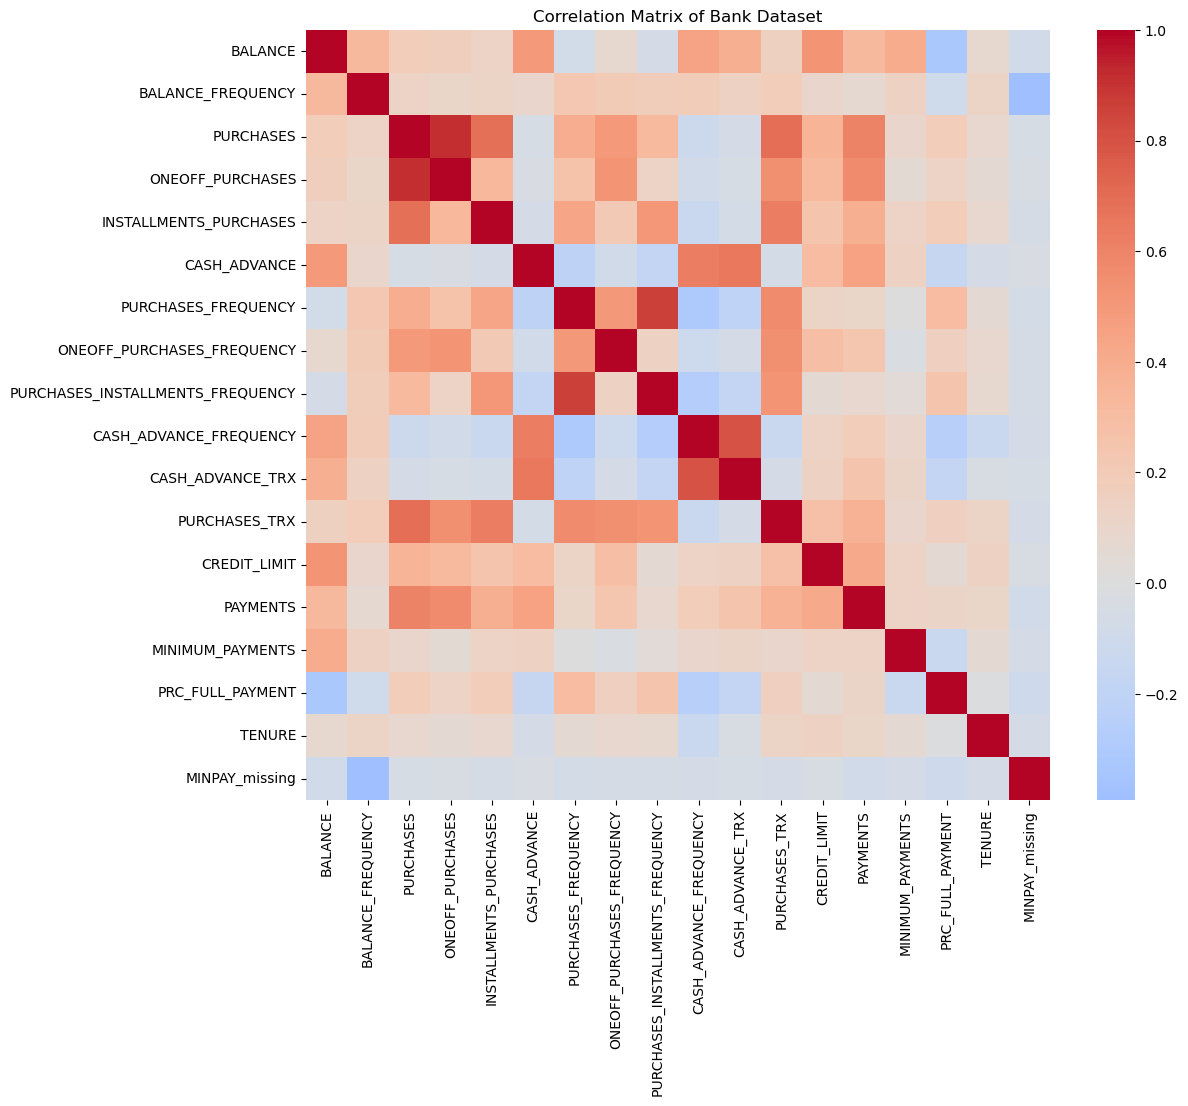

In [40]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title("Correlation Matrix of Bank Dataset")
plt.show()

In [42]:
threshold = 0.6

corr_abs = corr_matrix.abs()
upper_tri = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

strong_pairs = (
    upper_tri
    .stack()
    .reset_index()
)

strong_pairs.columns = ['feature_1', 'feature_2', 'correlation']

strong_pairs = strong_pairs[strong_pairs['correlation'] > threshold]

strong_pairs

,feature_1,feature_2,correlation
33,PURCHASES,ONEOFF_PURCHASES,0.916845
34,PURCHASES,INSTALLMENTS_PURCHASES,0.679896
41,PURCHASES,PURCHASES_TRX,0.689561
43,PURCHASES,PAYMENTS,0.603264
68,INSTALLMENTS_PURCHASES,PURCHASES_TRX,0.628108
78,CASH_ADVANCE,CASH_ADVANCE_FREQUENCY,0.628522
79,CASH_ADVANCE,CASH_ADVANCE_TRX,0.656498
88,PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,0.862934
117,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,0.799561


### Outliers Detection 

In [43]:
def detect_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < Q1 - 1.5 * IQR) | (series > Q3 + 1.5 * IQR)]
    return outliers, lower, upper

In [44]:
outlier_summary = {}
for col in numeric_features:
    outliers, lower, upper = detect_outliers(cc_imputed[col])
    count = len(outliers)
    percent = count / len(cc_imputed) * 100

    outlier_summary[col] = {'Count': count, 'Percentage': percent, 'Outliers Below': lower, 'Outliers Above': upper}

outlier_df = pd.DataFrame(outlier_summary).T
display(outlier_df)

,Count,Percentage,Outliers Below,Outliers Above
BALANCE,695.0,7.765363,-2760.505265,4942.927215
BALANCE_FREQUENCY,1493.0,16.681564,0.722223,1.166666
PURCHASES,808.0,9.027933,-1566.107500,2715.872500
ONEOFF_PURCHASES,1013.0,11.318436,-866.107500,1443.512500
INSTALLMENTS_PURCHASES,867.0,9.687151,-702.956250,1171.593750
CASH_ADVANCE,1030.0,11.508380,-1670.731709,2784.552848
PURCHASES_FREQUENCY,0.0,0.000000,-1.166668,2.166668
ONEOFF_PURCHASES_FREQUENCY,782.0,8.737430,-0.450000,0.750000
PURCHASES_INSTALLMENTS_FREQUENCY,0.0,0.000000,-1.125000,1.875000
CASH_ADVANCE_FREQUENCY,525.0,5.865922,-0.333333,0.555555


## **2. Data Preparation**

- Drop irrelevant or target columns
- Encode categorical features into numeric format
- Scale numeric features so all are comparable for distance calculations  
- Check that the final dataset has **no missing values** and **all features are numeric** 

In [45]:
cc_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BALANCE                           8950 non-null   float64
 1   BALANCE_FREQUENCY                 8950 non-null   float64
 2   PURCHASES                         8950 non-null   float64
 3   ONEOFF_PURCHASES                  8950 non-null   float64
 4   INSTALLMENTS_PURCHASES            8950 non-null   float64
 5   CASH_ADVANCE                      8950 non-null   float64
 6   PURCHASES_FREQUENCY               8950 non-null   float64
 7   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 8   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 9   CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 10  CASH_ADVANCE_TRX                  8950 non-null   int64  
 11  PURCHASES_TRX                     8950 non-null   int64  
 12  CREDIT

In [47]:
cc_imputed.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.0,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.0,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.0,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.0,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.0,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.0,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.0,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.0,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.0,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.0,0.000000,0.000000,0.222222,1.50000


### Already dropped CUST_ID

### No categorical features to encode

### Numeric Scaling

In [50]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

cc_numeric = cc_imputed[numeric_features].copy()

scaler = StandardScaler()

# Fit and transform
cc_scaled = scaler.fit_transform(cc_numeric)

cc_scaled_df = pd.DataFrame(cc_scaled, columns=numeric_features)

cc_scaled_df.describe().round(2)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00
mean,-0.00,0.00,0.00,-0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.75,-3.70,-0.47,-0.36,-0.45,-0.47,-1.22,-0.68,-0.92,-0.68,-0.48,-0.59,-1.22,-0.60,-0.36,-0.53,-4.12
25%,-0.69,0.05,-0.45,-0.36,-0.45,-0.47,-1.01,-0.68,-0.92,-0.68,-0.48,-0.55,-0.80,-0.47,-0.29,-0.53,0.36
50%,-0.33,0.52,-0.30,-0.33,-0.36,-0.47,0.02,-0.40,-0.50,-0.68,-0.48,-0.31,-0.41,-0.30,-0.23,-0.53,0.36
75%,0.24,0.52,0.05,-0.01,0.06,0.06,1.06,0.33,0.97,0.44,0.11,0.09,0.55,0.06,-0.02,-0.04,0.36
max,8.40,0.52,22.48,24.20,24.43,22.01,1.27,2.67,1.60,6.82,17.55,13.81,7.01,16.92,32.35,2.89,0.36


In [51]:
cc_scaled_df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,-2.540488e-17,1.000056,-0.751640,-0.690008,-0.332029,0.235256,8.397489
BALANCE_FREQUENCY,8950.0,1.587805e-16,1.000056,-3.703271,0.049045,0.518084,0.518084,0.518084
PURCHASES,8950.0,3.175610e-18,1.000056,-0.469552,-0.451001,-0.300454,0.050047,22.483510
ONEOFF_PURCHASES,8950.0,-6.033659e-17,1.000056,-0.356934,-0.356934,-0.334040,-0.009057,24.201066
INSTALLMENTS_PURCHASES,8950.0,3.175610e-17,1.000056,-0.454576,-0.454576,-0.356156,0.063663,24.426889
CASH_ADVANCE,8950.0,-6.351220e-18,1.000056,-0.466786,-0.466786,-0.466786,0.064352,22.011117
PURCHASES_FREQUENCY,8950.0,9.328354e-17,1.000056,-1.221758,-1.014125,0.024043,1.062211,1.269843
ONEOFF_PURCHASES_FREQUENCY,8950.0,1.905366e-17,1.000056,-0.678661,-0.678661,-0.399319,0.326973,2.673451
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,5.716098e-17,1.000056,-0.916995,-0.916995,-0.497629,0.970151,1.599199
CASH_ADVANCE_FREQUENCY,8950.0,-1.595744e-16,1.000056,-0.675349,-0.675349,-0.675349,0.435149,6.820521


In [52]:
cc_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BALANCE                           8950 non-null   float64
 1   BALANCE_FREQUENCY                 8950 non-null   float64
 2   PURCHASES                         8950 non-null   float64
 3   ONEOFF_PURCHASES                  8950 non-null   float64
 4   INSTALLMENTS_PURCHASES            8950 non-null   float64
 5   CASH_ADVANCE                      8950 non-null   float64
 6   PURCHASES_FREQUENCY               8950 non-null   float64
 7   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 8   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 9   CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 10  CASH_ADVANCE_TRX                  8950 non-null   int64  
 11  PURCHASES_TRX                     8950 non-null   int64  
 12  CREDIT

### Checking if any missing

In [53]:
sum_null_per_column=cc_scaled_df.isnull().sum()
sum_null_per_column

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

## **3. Apply Agglomerative Clustering**

In [55]:
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [109]:
X = cc_scaled_df.values

In [143]:
# Create the model
agg = AgglomerativeClustering(
    n_clusters=3,       
    metric='euclidean', 
    linkage='ward'      
)

# Fit and predict cluster labels
labels = agg.fit_predict(X)


## **4. Visualize the Clustering Results**

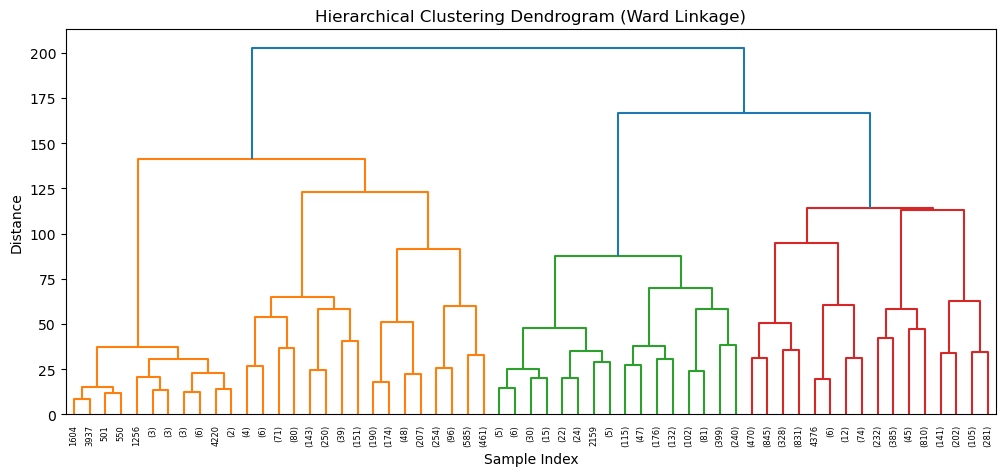

In [142]:
# Compute linkage matrix
Z = linkage(X, method='ward', metric='euclidean')

# Plot dendrogram
plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode='level', p=5)  # truncate to top 5 levels for readability
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()

## **5. Evaluate the Clustering**

In [144]:
cluster_counts = pd.Series(labels).value_counts().sort_index()
print("Cluster sizes:\n", cluster_counts)

Cluster sizes:
 0    2782
1    4768
2    1400
Name: count, dtype: int64


In [145]:
score = silhouette_score(X, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.1759267718507881


In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

sil_scores = {}
for k in range(2, 11):  # test 2 to 10 clusters
    agg = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='average')
    labels = agg.fit_predict(X)
    sil_scores[k] = silhouette_score(X, labels)

best_k = max(sil_scores, key=sil_scores.get)
print(f"Best n_clusters={best_k}, Silhouette Score={sil_scores[best_k]:.4f}")

Best n_clusters=2, Silhouette Score=0.7771


In [131]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

sil_scores = {}
for k in range(2, 11):  # test 2 to 10 clusters
    agg = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='complete')
    labels = agg.fit_predict(X)
    sil_scores[k] = silhouette_score(X, labels)

best_k = max(sil_scores, key=sil_scores.get)
print(f"Best n_clusters={best_k}, Silhouette Score={sil_scores[best_k]:.4f}")

Best n_clusters=2, Silhouette Score=0.7865


In [132]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

sil_scores = {}
for k in range(2, 11):  # test 2 to 10 clusters
    agg = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    labels = agg.fit_predict(X)
    sil_scores[k] = silhouette_score(X, labels)

best_k = max(sil_scores, key=sil_scores.get)
print(f"Best n_clusters={best_k}, Silhouette Score={sil_scores[best_k]:.4f}")

Best n_clusters=2, Silhouette Score=0.1883


In [133]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

sil_scores = {}
for k in range(2, 11):  # test 2 to 10 clusters
    agg = AgglomerativeClustering(n_clusters=k, metric='manhattan', linkage='complete')
    labels = agg.fit_predict(X)
    sil_scores[k] = silhouette_score(X, labels)

best_k = max(sil_scores, key=sil_scores.get)
print(f"Best n_clusters={best_k}, Silhouette Score={sil_scores[best_k]:.4f}")

Best n_clusters=2, Silhouette Score=0.7771


In [134]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

sil_scores = {}
for k in range(2, 11):  # test 2 to 10 clusters
    agg = AgglomerativeClustering(n_clusters=k, metric='manhattan', linkage='average')
    labels = agg.fit_predict(X)
    sil_scores[k] = silhouette_score(X, labels)

best_k = max(sil_scores, key=sil_scores.get)
print(f"Best n_clusters={best_k}, Silhouette Score={sil_scores[best_k]:.4f}")

Best n_clusters=2, Silhouette Score=0.8408


## **6. Explain whether the clustering quality and justify your reasoning**

The clustering quality was evaluated using the silhouette score, which measures how well each point lies within its cluster relative to other clusters. While a higher silhouette score generally indicates better-defined clusters, it does not always guarantee meaningful clusters in practice. For example, when using average linkage with Manhattan distance, the silhouette score was actually the highest among the methods tested. However, this configuration produced 2 clusters, one of which contained only a single data point, which is clearly not useful for analysis.

In contrast, using Ward linkage with Euclidean distance produced three clusters with sizes 2782, 4768, and 1400 customers. The silhouette score of 0.176 indicates weak separation, which is expected for real-world financial data where customer behavior varies continuously. Despite the low score, the clusters are reasonably balanced, unlike other methods that gave higher silhouette scores but created tiny clusters with very few points. Therefore, using Ward linkage with Euclidean distance was chosen to balance cluster interpretability and statistical separation.